In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q segmentation-models-pytorch albumentations opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.9 MB/s eta 0:00:00


In [3]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: False


In [4]:
import zipfile
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/IRP/RUGD.zip")
extract_root = Path("/content/RUGD_raw")

extract_root.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_root)

print("Extracted to:", extract_root)

Extracted to: /content/RUGD_raw


In [5]:
!find /content/RUGD_raw -maxdepth 3 -type d | head -50

/content/RUGD_raw
/content/RUGD_raw/RUGD
/content/RUGD_raw/RUGD/RUGD_frames-with-annotations
/content/RUGD_raw/RUGD/RUGD_frames-with-annotations/RUGD_frames-with-annotations
/content/RUGD_raw/RUGD/RUGD_annotations
/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_annotations


In [6]:
RAW_ROOT = Path("/content/RUGD_raw/RUGD")

In [7]:
from pathlib import Path

RAW_ROOT = Path("/content/RUGD_raw/RUGD")

IMAGE_ROOT = RAW_ROOT / "RUGD_frames-with-annotations/RUGD_frames-with-annotations"
MASK_ROOT = RAW_ROOT / "RUGD_annotations/RUGD_annotations"

print("IMAGE_ROOT exists:", IMAGE_ROOT.exists(), IMAGE_ROOT)
print("MASK_ROOT exists:", MASK_ROOT.exists(), MASK_ROOT)

print("Sequences in image root:")
print([p.name for p in IMAGE_ROOT.iterdir() if p.is_dir()][:20])

IMAGE_ROOT exists: True /content/RUGD_raw/RUGD/RUGD_frames-with-annotations/RUGD_frames-with-annotations
MASK_ROOT exists: True /content/RUGD_raw/RUGD/RUGD_annotations/RUGD_annotations
Sequences in image root:
['trail-14', 'trail-5', 'trail-13', 'park-2', 'trail-4', 'trail-12', 'village', 'trail-15', 'trail-6', 'park-8', 'trail-10', 'trail-7', 'creek', 'park-1', 'trail-11', 'trail-3', 'trail', 'trail-9']


In [8]:
import numpy as np

IGNORE_INDEX = 255

RUGD_ID_TO_CLASS = {
    0: "void",
    1: "dirt",
    2: "sand",
    3: "grass",
    4: "tree",
    5: "pole",
    6: "water",
    7: "sky",
    8: "vehicle",
    9: "container/generic-object",
    10: "asphalt",
    11: "gravel",
    12: "building",
    13: "mulch",
    14: "rock-bed",
    15: "log",
    16: "bicycle",
    17: "person",
    18: "fence",
    19: "bush",
    20: "sign",
    21: "rock",
    22: "bridge",
    23: "concrete",
    24: "picnic-table",
}

RUGD_COLOR_TO_ID = {
    (0, 0, 0): 0,
    (108, 64, 20): 1,
    (255, 229, 204): 2,
    (0, 102, 0): 3,
    (0, 255, 0): 4,
    (0, 153, 153): 5,
    (0, 128, 255): 6,
    (0, 0, 255): 7,
    (255, 255, 0): 8,
    (255, 0, 127): 9,
    (64, 64, 64): 10,
    (255, 128, 0): 11,
    (255, 0, 0): 12,
    (153, 76, 0): 13,
    (102, 102, 0): 14,
    (102, 0, 0): 15,
    (0, 255, 128): 16,
    (204, 153, 255): 17,
    (102, 0, 204): 18,
    (255, 153, 204): 19,
    (0, 102, 102): 20,
    (153, 204, 255): 21,
    (102, 255, 255): 22,
    (101, 101, 11): 23,
    (114, 85, 47): 24,
}

TRAIN_ID_TO_CLASS = {
    original_id - 1: class_name
    for original_id, class_name in RUGD_ID_TO_CLASS.items()
    if original_id != 0
}

print("Number of original classes including void:", len(RUGD_ID_TO_CLASS))
print("Number of training classes excluding void:", len(TRAIN_ID_TO_CLASS))
print(TRAIN_ID_TO_CLASS)

Number of original classes including void: 25
Number of training classes excluding void: 24
{0: 'dirt', 1: 'sand', 2: 'grass', 3: 'tree', 4: 'pole', 5: 'water', 6: 'sky', 7: 'vehicle', 8: 'container/generic-object', 9: 'asphalt', 10: 'gravel', 11: 'building', 12: 'mulch', 13: 'rock-bed', 14: 'log', 15: 'bicycle', 16: 'person', 17: 'fence', 18: 'bush', 19: 'sign', 20: 'rock', 21: 'bridge', 22: 'concrete', 23: 'picnic-table'}


In [9]:
def rgb_mask_to_original_id(mask_rgb: np.ndarray) -> np.ndarray:
    """
    Convert RUGD RGB annotation mask to original RUGD class ids.

    Original ids:
        0  = void
        1  = dirt
        ...
        24 = picnic-table
        255 = unknown color
    """
    h, w, _ = mask_rgb.shape
    mask_id = np.full((h, w), IGNORE_INDEX, dtype=np.uint8)

    for color, class_id in RUGD_COLOR_TO_ID.items():
        color_arr = np.array(color, dtype=np.uint8)
        matched = np.all(mask_rgb == color_arr, axis=-1)
        mask_id[matched] = class_id

    return mask_id


def remap_original_id_to_train_id(mask_id: np.ndarray) -> np.ndarray:
    """
    Convert original RUGD ids to training ids.

    Original:
        0  = void
        1  = dirt
        ...
        24 = picnic-table

    Training:
        255 = ignore
        0   = dirt
        1   = sand
        ...
        23  = picnic-table
    """
    train_mask = np.full(mask_id.shape, IGNORE_INDEX, dtype=np.uint8)

    valid = (mask_id >= 1) & (mask_id <= 24)
    train_mask[valid] = mask_id[valid] - 1

    return train_mask


def rgb_mask_to_train_id(mask_rgb: np.ndarray) -> np.ndarray:
    original_id = rgb_mask_to_original_id(mask_rgb)
    train_id = remap_original_id_to_train_id(original_id)
    return train_id

In [10]:
from PIL import Image

mask_paths = sorted(MASK_ROOT.rglob("*.png"))

print("Number of masks:", len(mask_paths))
print("Example mask:", mask_paths[0])

Number of masks: 7436
Example mask: /content/RUGD_raw/RUGD/RUGD_annotations/RUGD_annotations/creek/creek_00001.png


RGB mask shape: (550, 688, 3)
Original ids: [ 1  2  3  4  6  7  8  9 14 19 21 22]
Train ids: [ 0  1  2  3  5  6  7  8 13 18 20 21]
Unknown ratio: 0.0
Ignore ratio in train mask: 0.0


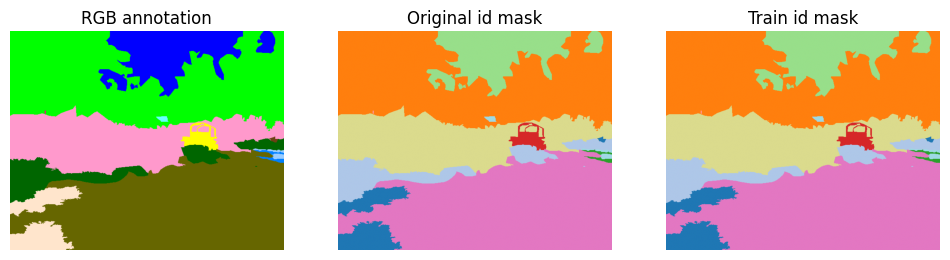

In [11]:
import matplotlib.pyplot as plt

example_mask_path = mask_paths[0]

mask_rgb = np.array(Image.open(example_mask_path).convert("RGB"))
mask_original = rgb_mask_to_original_id(mask_rgb)
mask_train = remap_original_id_to_train_id(mask_original)

print("RGB mask shape:", mask_rgb.shape)
print("Original ids:", np.unique(mask_original))
print("Train ids:", np.unique(mask_train))
print("Unknown ratio:", np.mean(mask_original == IGNORE_INDEX))
print("Ignore ratio in train mask:", np.mean(mask_train == IGNORE_INDEX))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("RGB annotation")
plt.imshow(mask_rgb)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Original id mask")
plt.imshow(mask_original, cmap="tab20")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Train id mask")
plt.imshow(mask_train, cmap="tab20")
plt.axis("off")

plt.show()

In [12]:
def collect_image_mask_pairs(image_root: Path, mask_root: Path):
    image_paths = sorted(image_root.rglob("*.png"))
    pairs = []

    missing = 0

    for image_path in image_paths:
        rel_path = image_path.relative_to(image_root)
        mask_path = mask_root / rel_path

        if mask_path.exists():
            pairs.append((image_path, mask_path))
        else:
            missing += 1

    print("Total images:", len(image_paths))
    print("Matched pairs:", len(pairs))
    print("Missing masks:", missing)

    return pairs


pairs = collect_image_mask_pairs(IMAGE_ROOT, MASK_ROOT)
pairs[:3]

Total images: 7436
Matched pairs: 7436
Missing masks: 0


[(PosixPath('/content/RUGD_raw/RUGD/RUGD_frames-with-annotations/RUGD_frames-with-annotations/creek/creek_00001.png'),
  PosixPath('/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_annotations/creek/creek_00001.png')),
 (PosixPath('/content/RUGD_raw/RUGD/RUGD_frames-with-annotations/RUGD_frames-with-annotations/creek/creek_00006.png'),
  PosixPath('/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_annotations/creek/creek_00006.png')),
 (PosixPath('/content/RUGD_raw/RUGD/RUGD_frames-with-annotations/RUGD_frames-with-annotations/creek/creek_00011.png'),
  PosixPath('/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_annotations/creek/creek_00011.png'))]

In [13]:
sequences = sorted([p.name for p in IMAGE_ROOT.iterdir() if p.is_dir()])
print("Number of sequences:", len(sequences))
print(sequences)

Number of sequences: 18
['creek', 'park-1', 'park-2', 'park-8', 'trail', 'trail-10', 'trail-11', 'trail-12', 'trail-13', 'trail-14', 'trail-15', 'trail-3', 'trail-4', 'trail-5', 'trail-6', 'trail-7', 'trail-9', 'village']


In [14]:
import random

random.seed(42)

sequences_shuffled = sequences.copy()
random.shuffle(sequences_shuffled)

n = len(sequences_shuffled)
n_train = int(0.7 * n)
n_val = int(0.15 * n)

train_sequences = sequences_shuffled[:n_train]
val_sequences = sequences_shuffled[n_train:n_train + n_val]
test_sequences = sequences_shuffled[n_train + n_val:]

print("Train sequences:", train_sequences)
print("Val sequences:", val_sequences)
print("Test sequences:", test_sequences)

Train sequences: ['trail-5', 'trail-4', 'trail', 'trail-14', 'trail-10', 'trail-12', 'trail-9', 'trail-11', 'trail-15', 'trail-7', 'park-1', 'trail-3']
Val sequences: ['park-2', 'trail-6']
Test sequences: ['village', 'trail-13', 'creek', 'park-8']


In [15]:
def split_pairs_by_sequence(pairs, train_sequences, val_sequences, test_sequences):
    split = {
        "train": [],
        "val": [],
        "test": [],
    }

    train_set = set(train_sequences)
    val_set = set(val_sequences)
    test_set = set(test_sequences)

    for image_path, mask_path in pairs:
        seq_name = image_path.relative_to(IMAGE_ROOT).parts[0]

        if seq_name in train_set:
            split["train"].append((image_path, mask_path))
        elif seq_name in val_set:
            split["val"].append((image_path, mask_path))
        elif seq_name in test_set:
            split["test"].append((image_path, mask_path))

    return split


split_pairs = split_pairs_by_sequence(
    pairs,
    train_sequences,
    val_sequences,
    test_sequences,
)

for split_name, items in split_pairs.items():
    print(split_name, len(items))

train 4859
val 1095
test 1482


In [16]:
import shutil
from tqdm import tqdm

PROCESSED_ROOT = Path("/content/RUGD_processed")

def prepare_processed_dataset(split_pairs, processed_root: Path):
    for split_name, items in split_pairs.items():
        image_out_dir = processed_root / "images" / split_name
        mask_out_dir = processed_root / "masks" / split_name

        image_out_dir.mkdir(parents=True, exist_ok=True)
        mask_out_dir.mkdir(parents=True, exist_ok=True)

        for image_path, mask_path in tqdm(items, desc=f"Processing {split_name}"):
            seq_name = image_path.relative_to(IMAGE_ROOT).parts[0]
            out_name = f"{seq_name}_{image_path.name}"

            out_image_path = image_out_dir / out_name
            out_mask_path = mask_out_dir / out_name

            shutil.copy2(image_path, out_image_path)

            mask_rgb = np.array(Image.open(mask_path).convert("RGB"))
            mask_train = rgb_mask_to_train_id(mask_rgb)

            Image.fromarray(mask_train).save(out_mask_path)

prepare_processed_dataset(split_pairs, PROCESSED_ROOT)

print("Processed dataset saved to:", PROCESSED_ROOT)

Processing test: 100%|██████████| 1482/1482 [06:33<00:00,  3.77it/s]

Processed dataset saved to: /content/RUGD_processed


In [17]:
!find /content/RUGD_processed -maxdepth 3 -type f | head

/content/RUGD_processed/images/train/trail_trail_02811.png
/content/RUGD_processed/images/train/trail-15_trail-15_00071.png
/content/RUGD_processed/images/train/trail-4_trail-4_03691.png
/content/RUGD_processed/images/train/park-1_park-1_02136.png
/content/RUGD_processed/images/train/trail-11_trail-11_01656.png
/content/RUGD_processed/images/train/trail-4_trail-4_00196.png
/content/RUGD_processed/images/train/trail-11_trail-11_01141.png
/content/RUGD_processed/images/train/trail_trail_01236.png
/content/RUGD_processed/images/train/trail-3_trail-3_02556.png
/content/RUGD_processed/images/train/trail-4_trail-4_02571.png


In [18]:
processed_mask_paths = sorted((PROCESSED_ROOT / "masks" / "train").glob("*.png"))

sample_processed_mask = np.array(Image.open(processed_mask_paths[0]))

print("Processed mask shape:", sample_processed_mask.shape)
print("Unique values:", np.unique(sample_processed_mask))
print("Min:", sample_processed_mask.min())
print("Max:", sample_processed_mask.max())

Processed mask shape: (550, 688)
Unique values: [ 0  2  3  4  6  7 10 11 17 22]
Min: 0
Max: 22


In [19]:
from pathlib import Path
from PIL import Image
import numpy as np
from tqdm import tqdm

PROCESSED_ROOT = Path("/content/RUGD_processed")

all_mask_paths = sorted((PROCESSED_ROOT / "masks").rglob("*.png"))

all_values = set()
bad_masks = []

for mask_path in tqdm(all_mask_paths):
    mask = np.array(Image.open(mask_path))
    values = np.unique(mask)

    all_values.update(values.tolist())

    for v in values:
        if not (0 <= v <= 23 or v == 255):
            bad_masks.append((mask_path, v))

all_values = sorted(all_values)

print("Number of masks:", len(all_mask_paths))
print("All unique values in processed masks:")
print(all_values)

print("Number of bad masks:", len(bad_masks))
if bad_masks:
    print("Examples of bad masks:")
    for item in bad_masks[:10]:
        print(item)

100%|██████████| 7436/7436 [00:58<00:00, 126.34it/s]

Number of masks: 7436
All unique values in processed masks:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 255]
Number of bad masks: 0


In [20]:
for split in ["train", "val", "test"]:
    image_dir = PROCESSED_ROOT / "images" / split
    mask_dir = PROCESSED_ROOT / "masks" / split

    image_count = len(list(image_dir.glob("*.png")))
    mask_count = len(list(mask_dir.glob("*.png")))

    print(split)
    print("images:", image_count)
    print("masks: ", mask_count)
    print("match: ", image_count == mask_count)
    print()

train
images: 4859
masks:  4859
match:  True

val
images: 1095
masks:  1095
match:  True

test
images: 1482
masks:  1482
match:  True



In [21]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import numpy as np

class RUGDProcessedDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform

        self.image_paths = sorted(self.image_dir.glob("*.png"))

        if len(self.image_paths) == 0:
            raise RuntimeError(f"No images found in {self.image_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.mask_dir / image_path.name

        if not mask_path.exists():
            raise FileNotFoundError(f"Missing mask: {mask_path}")

        image = np.array(Image.open(image_path).convert("RGB"))
        mask = np.array(Image.open(mask_path))

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"].long()
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()

        return image, mask

In [22]:
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2(),
])

In [23]:
BATCH_SIZE = 4

train_dataset = RUGDProcessedDataset(
    image_dir=PROCESSED_ROOT / "images" / "train",
    mask_dir=PROCESSED_ROOT / "masks" / "train",
    transform=train_transform,
)

val_dataset = RUGDProcessedDataset(
    image_dir=PROCESSED_ROOT / "images" / "val",
    mask_dir=PROCESSED_ROOT / "masks" / "val",
    transform=val_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

images, masks = next(iter(train_loader))

print("Image batch:", images.shape, images.dtype)
print("Mask batch:", masks.shape, masks.dtype)
print("Mask unique values:", torch.unique(masks))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image batch: torch.Size([4, 3, 512, 512]) torch.float32
Mask batch: torch.Size([4, 512, 512]) torch.int64
Mask unique values: tensor([ 1,  2,  3,  6,  7,  8, 10, 11, 12, 13, 14])


In [24]:
import segmentation_models_pytorch as smp
import torch.nn as nn

NUM_CLASSES = 24

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

print("Model ready on:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model ready on: cpu


In [25]:
def compute_miou(preds, targets, num_classes=24, ignore_index=255):
    """
    preds:   B x H x W
    targets: B x H x W
    """
    preds = preds.detach().cpu().numpy()
    targets = targets.detach().cpu().numpy()

    ious = []

    for cls in range(num_classes):
        pred_cls = preds == cls
        target_cls = targets == cls

        valid = targets != ignore_index

        pred_cls = pred_cls & valid
        target_cls = target_cls & valid

        intersection = np.logical_and(pred_cls, target_cls).sum()
        union = np.logical_or(pred_cls, target_cls).sum()

        if union == 0:
            continue

        iou = intersection / union
        ious.append(iou)

    if len(ious) == 0:
        return 0.0

    return float(np.mean(ious))

In [26]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0

    for images, masks in tqdm(loader, desc="Training"):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, num_classes=24):
    model.eval()

    total_loss = 0.0
    miou_scores = []

    for images, masks in tqdm(loader, desc="Validation"):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)

        preds = torch.argmax(logits, dim=1)

        miou = compute_miou(
            preds=preds,
            targets=masks,
            num_classes=num_classes,
            ignore_index=IGNORE_INDEX,
        )

        total_loss += loss.item() * images.size(0)
        miou_scores.append(miou)

    avg_loss = total_loss / len(loader.dataset)
    avg_miou = float(np.mean(miou_scores))

    return avg_loss, avg_miou

In [27]:
EPOCHS = 5

best_val_miou = 0.0
save_path = Path("/content/drive/MyDrive/IRP_robot/checkpoints")
save_path.mkdir(parents=True, exist_ok=True)

best_model_path = save_path / "unet_resnet34_rugd_best.pth"

history = {
    "train_loss": [],
    "val_loss": [],
    "val_miou": [],
}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{EPOCHS}]")

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_loss, val_miou = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        num_classes=NUM_CLASSES,
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_miou)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val mIoU:   {val_miou:.4f}")

    if val_miou > best_val_miou:
        best_val_miou = val_miou

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_miou": best_val_miou,
            "num_classes": NUM_CLASSES,
            "encoder_name": "resnet34",
            "ignore_index": IGNORE_INDEX,
            "train_id_to_class": TRAIN_ID_TO_CLASS,
        }, best_model_path)

        print(f"Saved best model to: {best_model_path}")


Epoch [1/5]


Training:   0%|          | 0/1215 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Training:   0%|          | 1/1215 [00:39<13:28:40, 39.97s/it]


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_predictions(model, dataset, device, num_samples=3):
    model.eval()

    for i in range(num_samples):
        image, mask = dataset[i]

        input_tensor = image.unsqueeze(0).to(device)
        logits = model(input_tensor)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

        image_np = image.permute(1, 2, 0).cpu().numpy()

        # de-normalize for visualization
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image_np = std * image_np + mean
        image_np = np.clip(image_np, 0, 1)

        mask_np = mask.cpu().numpy()

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.title("Image")
        plt.imshow(image_np)
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.title("Ground Truth")
        plt.imshow(mask_np, cmap="tab20", vmin=0, vmax=23)
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.title("Prediction")
        plt.imshow(pred, cmap="tab20", vmin=0, vmax=23)
        plt.axis("off")

        plt.show()


visualize_predictions(model, val_dataset, device, num_samples=3)

In [29]:
!zip -r -q /content/RUGD_processed.zip /content/RUGD_processed
!cp /content/RUGD_processed.zip /content/drive/MyDrive/IRP/RUGD_processed.zip

In [30]:
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/IRP/RUGD_processed.zip")

print("Zip exists:", zip_path.exists())
print("Zip path:", zip_path)

if zip_path.exists():
    size_gb = zip_path.stat().st_size / (1024 ** 3)
    print(f"Zip size: {size_gb:.2f} GB")

Zip exists: True
Zip path: /content/drive/MyDrive/IRP/RUGD_processed.zip
Zip size: 5.33 GB


In [31]:
import zipfile

with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()

print("Number of files in zip:", len(names))
print("First 20 files:")
for name in names[:20]:
    print(name)

Number of files in zip: 14881
First 20 files:
content/RUGD_processed/
content/RUGD_processed/images/
content/RUGD_processed/images/train/
content/RUGD_processed/images/train/trail_trail_02811.png
content/RUGD_processed/images/train/trail-15_trail-15_00071.png
content/RUGD_processed/images/train/trail-4_trail-4_03691.png
content/RUGD_processed/images/train/park-1_park-1_02136.png
content/RUGD_processed/images/train/trail-11_trail-11_01656.png
content/RUGD_processed/images/train/trail-4_trail-4_00196.png
content/RUGD_processed/images/train/trail-11_trail-11_01141.png
content/RUGD_processed/images/train/trail_trail_01236.png
content/RUGD_processed/images/train/trail-3_trail-3_02556.png
content/RUGD_processed/images/train/trail-4_trail-4_02571.png
content/RUGD_processed/images/train/trail_trail_02471.png
content/RUGD_processed/images/train/trail-12_trail-12_00436.png
content/RUGD_processed/images/train/park-1_park-1_00976.png
content/RUGD_processed/images/train/trail-12_trail-12_00136.png


In [32]:
with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()

image_train = [n for n in names if "/images/train/" in n and n.endswith(".png")]
image_val = [n for n in names if "/images/val/" in n and n.endswith(".png")]
image_test = [n for n in names if "/images/test/" in n and n.endswith(".png")]

mask_train = [n for n in names if "/masks/train/" in n and n.endswith(".png")]
mask_val = [n for n in names if "/masks/val/" in n and n.endswith(".png")]
mask_test = [n for n in names if "/masks/test/" in n and n.endswith(".png")]

print("images/train:", len(image_train))
print("masks/train: ", len(mask_train))
print("images/val:  ", len(image_val))
print("masks/val:   ", len(mask_val))
print("images/test: ", len(image_test))
print("masks/test:  ", len(mask_test))

print("Train match:", len(image_train) == len(mask_train))
print("Val match:  ", len(image_val) == len(mask_val))
print("Test match: ", len(image_test) == len(mask_test))

images/train: 4859
masks/train:  4859
images/val:   1095
masks/val:    1095
images/test:  1482
masks/test:   1482
Train match: True
Val match:   True
Test match:  True
